# Test-Retest-Reproduzierbarkeit der News-Annotationen

Dieses Notebook untersucht, wie stabil das lokale LLM dieselben News-Inhalte bei einer wiederholten Annotation bewertet. Dafür werden die Annotationen des `main_run`, aus denen die verwendeten News-Features gebildet wurden, mit den separat erzeugten Annotationen des `second_run` über ihre `task_id` gepaart.

Beide Annotationsläufe wurden auf derselben Hardware mit einer AMD Radeon RX 7800 XT und mit exakt identischer Konfiguration durchgeführt. Damit bleiben die technischen Versuchsbedingungen zwischen `main_run` und `second_run` konstant.

> Die Übereinstimmung misst die Reproduzierbarkeit der Annotationen, nicht ihre inhaltliche Richtigkeit.

In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import MaxNLocator

from buli_news.news.annotations.results import read_existing_annotations

SEASON = 2025
MAIN_RUN_PATH = Path(f"../data/interim/{SEASON}/news/annotations/results.jsonl")
SECOND_RUN_PATH = Path(
    f"../data/interim/{SEASON}/news/annotations/pilots/v3/reproducibility/"
    "results_200_seed_20250903_workers_2_replicate_1.jsonl"
)
INDICATOR_LABELS = {
    "sporting_form": "Sportliche Form",
    "personnel_situation": "Personalsituation",
    "physical_readiness": "Physische Einsatzbereitschaft",
    "confidence_and_motivation": "Selbstvertrauen und Motivation",
}
RUNS = ("main_run", "second_run")
RATING_VALUES = {
    "strong_negative": -2,
    "negative": -1,
    "neutral": 0,
    "positive": 1,
    "strong_positive": 2,
}

In [79]:
def map_by_task_id(annotations: list[dict], label: str) -> dict[str, dict]:
    mapping = {annotation["task_id"]: annotation for annotation in annotations}
    if len(mapping) != len(annotations):
        raise ValueError(f"{label} enthält doppelte task_id-Werte.")
    return mapping


main_run_annotations = read_existing_annotations(MAIN_RUN_PATH)
second_run_annotations = read_existing_annotations(SECOND_RUN_PATH)

main_run_by_task_id = map_by_task_id(main_run_annotations, "main_run")
second_run_by_task_id = map_by_task_id(
    second_run_annotations,
    "second_run",
)

missing_main_run_task_ids = set(second_run_by_task_id) - set(main_run_by_task_id)
if missing_main_run_task_ids:
    raise ValueError(
        f"Für {len(missing_main_run_task_ids)} Annotationen aus dem second_run fehlt "
        "die zugehörige Annotation aus dem main_run."
    )

annotation_pairs = {
    task_id: {
        "main_run": main_run_by_task_id[task_id],
        "second_run": second_run_annotation,
    }
    for task_id, second_run_annotation in second_run_by_task_id.items()
}

print(f"main_run: {len(main_run_annotations)} Annotationen")
print(f"second_run: {len(second_run_annotations)} Annotationen")
print(f"Gepaarte Annotationen: {len(annotation_pairs)}")

main_run: 48465 Annotationen
second_run: 200 Annotationen
Gepaarte Annotationen: 200


## 1. Häufigkeit der vier Indikatoren

Die Tabelle zeigt für beide Annotationsläufe, wie oft der jeweilige Indikator in den 200 gepaarten Tasks tatsächlich erwähnt und bewertet wurde. Ein Indikator wird gezählt, wenn sein Rating nicht `not_mentioned` ist.

In [80]:
annotation_counts = pd.DataFrame([
    {
        "Annotationslauf": run,
        **{
            indicator_label: sum(
                pair[run][indicator]["rating"] != "not_mentioned"
                for pair in annotation_pairs.values()
            )
            for indicator, indicator_label in INDICATOR_LABELS.items()
        },
    }
    for run in RUNS
])

display(annotation_counts)

,Annotationslauf,Sportliche Form,Personalsituation,Physische Einsatzbereitschaft,Selbstvertrauen und Motivation
0,main_run,63,23,7,25
1,second_run,61,18,6,23


### Relative Häufigkeit

Die relative Häufigkeit setzt die Anzahl der Erwähnungen ins Verhältnis zu den 200 gepaarten Tasks des jeweiligen Laufs.

In [81]:
indicator_columns = list(INDICATOR_LABELS.values())
relative_annotation_counts = annotation_counts.copy()
relative_annotation_counts[indicator_columns] = (
    relative_annotation_counts[indicator_columns] / len(annotation_pairs)
)

relative_annotation_counts_display = relative_annotation_counts.copy()
relative_annotation_counts_display[indicator_columns] = (
    relative_annotation_counts_display[indicator_columns].map(
        lambda value: f"{value:.1%}"
    )
)

display(relative_annotation_counts_display)

,Annotationslauf,Sportliche Form,Personalsituation,Physische Einsatzbereitschaft,Selbstvertrauen und Motivation
0,main_run,31.5%,11.5%,3.5%,12.5%
1,second_run,30.5%,9.0%,3.0%,11.5%


## 2. Verteilung der Bewertungen innerhalb der Indikatoren

Nach der Häufigkeit der Erwähnungen betrachten wir nun die Verteilung der tatsächlich vergebenen Bewertungen von `strong_negative` (−2) bis `strong_positive` (+2). `not_mentioned` wird hier ausgeschlossen. Die Balken zeigen die jeweilige Anzahl der erwähnten Fälle.

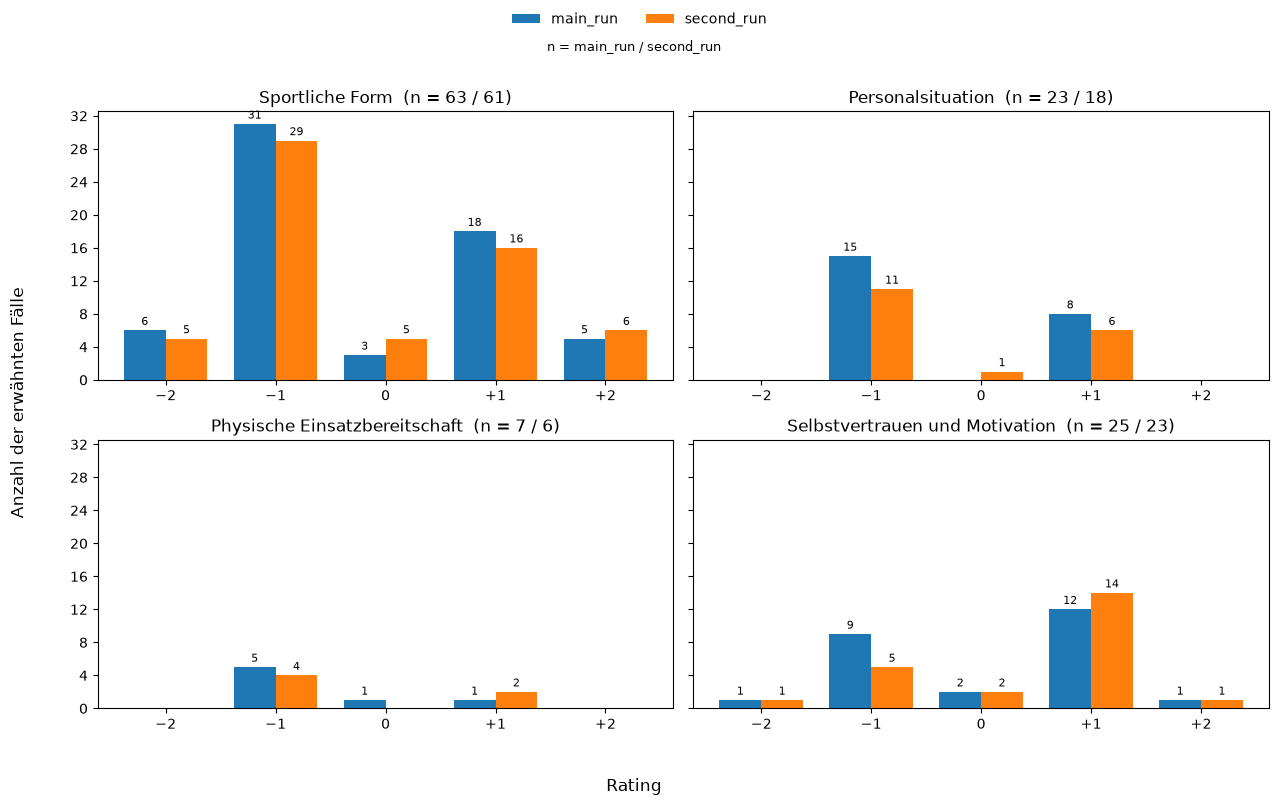

In [82]:
rating_distribution_rows = []
for run in RUNS:
    for indicator, indicator_label in INDICATOR_LABELS.items():
        ratings = [
            pair[run][indicator]["rating"]
            for pair in annotation_pairs.values()
            if pair[run][indicator]["rating"] != "not_mentioned"
        ]
        rating_distribution_rows.append({
            "Annotationslauf": run,
            "Indikator": indicator_label,
            "Bewertete Tasks": len(ratings),
            **{
                rating: ratings.count(rating)
                for rating in RATING_VALUES
            },
        })

rating_distribution_counts = pd.DataFrame(rating_distribution_rows)
rating_columns = list(RATING_VALUES)
rating_ticks = ["−2", "−1", "0", "+1", "+2"]
x_positions = list(range(len(rating_columns)))
bar_width = 0.38

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, indicator_label in zip(
    axes.flat,
    INDICATOR_LABELS.values(),
):
    indicator_rows = rating_distribution_counts[
        rating_distribution_counts["Indikator"] == indicator_label
    ].set_index("Annotationslauf")

    for run_index, run in enumerate(RUNS):
        values = indicator_rows.loc[run, rating_columns].to_numpy(dtype=int)
        offset = (run_index - 0.5) * bar_width
        bars = ax.bar(
            [position + offset for position in x_positions],
            values,
            width=bar_width,
            label=run,
        )
        ax.bar_label(
            bars,
            labels=[str(value) if value > 0 else "" for value in values],
            padding=2,
            fontsize=8,
        )

    main_n = int(indicator_rows.loc["main_run", "Bewertete Tasks"])
    second_n = int(indicator_rows.loc["second_run", "Bewertete Tasks"])
    ax.set_title(f"{indicator_label}  (n = {main_n} / {second_n})")
    ax.set_xticks(x_positions, rating_ticks)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.supxlabel("Rating")
fig.supylabel("Anzahl der erwähnten Fälle")
fig.text(0.5, 0.94, "n = main_run / second_run", ha="center", fontsize=9)
fig.tight_layout(rect=(0.03, 0.03, 1, 0.91))
plt.show()

## 3. Anzahl abweichender Indikatoren pro Task

Für jeden der 200 gepaarten Tasks wird gezählt, bei wie vielen der vier Indikatoren sich das Rating zwischen `main_run` und `second_run` unterscheidet. Null Abweichungen bedeuten, dass beide Läufe für alle vier Indikatoren dasselbe Rating ausgegeben haben.

In [83]:
different_indicators_per_task = [
    sum(
        pair["main_run"][indicator]["rating"]
        != pair["second_run"][indicator]["rating"]
        for indicator in INDICATOR_LABELS
    )
    for pair in annotation_pairs.values()
]
difference_counts = pd.Series(different_indicators_per_task).value_counts()
difference_counts = difference_counts.reindex(range(5), fill_value=0)

task_agreement = pd.DataFrame({
    "Abweichende Indikatoren": range(5),
    "Anzahl Tasks": difference_counts.to_numpy(),
    "Anteil": difference_counts.to_numpy() / len(annotation_pairs),
})
task_agreement_display = task_agreement.copy()
task_agreement_display["Anteil"] = task_agreement_display["Anteil"].map(
    lambda value: f"{value:.1%}"
)

display(task_agreement_display)

,Abweichende Indikatoren,Anzahl Tasks,Anteil
0,0,176,88.0%
1,1,23,11.5%
2,2,0,0.0%
3,3,1,0.5%
4,4,0,0.0%


Bei **176 der 200 Tasks (88,0 %)** stimmen die Ratings aller vier Indikatoren vollständig überein. Bei **23 Tasks (11,5 %)** unterscheidet sich genau ein Indikator. Nur bei einem Task weichen drei Indikatoren ab.

### Art und Stärke der Abweichung

Diese Untersuchung zeigt, ob die unterschiedlichen Ratings vor allem durch eine abweichende Erkennung von Erwähnungen, kleinere Bewertungsunterschiede oder tatsächlich gegensätzliche Einschätzungen entstehen.

In [84]:
indicator_difference_types = []
for pair in annotation_pairs.values():
    for indicator in INDICATOR_LABELS:
        main_rating = pair["main_run"][indicator]["rating"]
        second_rating = pair["second_run"][indicator]["rating"]
        if main_rating == second_rating:
            continue

        if "not_mentioned" in (main_rating, second_rating):
            difference_type = "Mention-Wechsel"
        else:
            main_value = RATING_VALUES[main_rating]
            second_value = RATING_VALUES[second_rating]
            if main_value * second_value < 0:
                difference_type = "Polaritätswechsel"
            elif 0 in (main_value, second_value):
                difference_type = "Wechsel mit neutral"
            else:
                difference_type = "Intensitätswechsel"

        indicator_difference_types.append(difference_type)

difference_type_order = [
    "Mention-Wechsel",
    "Wechsel mit neutral",
    "Intensitätswechsel",
    "Polaritätswechsel",
]
difference_type_counts = (
    pd.Series(indicator_difference_types)
    .value_counts()
    .reindex(difference_type_order, fill_value=0)
)
difference_type_summary = pd.DataFrame({
    "Abweichungsart": difference_type_order,
    "Anzahl": difference_type_counts.to_numpy(),
})

display(difference_type_summary)

,Abweichungsart,Anzahl
0,Mention-Wechsel,18
1,Wechsel mit neutral,4
2,Intensitätswechsel,2
3,Polaritätswechsel,2


- **Mention-Wechsel:** Ein Lauf erkennt eine Erwähnung und vergibt ein Rating, während der andere Lauf `not_mentioned` ausgibt.

- **Wechsel mit neutral:** Beide Läufe erkennen eine Erwähnung, aber nur einer bewertet sie als `neutral` und der andere vergibt ein positives oder negatives Rating.

- **Intensitätswechsel:** Beide Läufe bewerten den Indikator in dieselbe Richtung, unterscheiden sich aber in der Stärke, beispielsweise `negative` gegenüber `strong_negative`.

- **Polaritätswechsel:** Ein Lauf bewertet den Indikator negativ und der andere positiv. Dies ist der stärkste inhaltliche Widerspruch zwischen zwei Ratings.